# Life Cycle Economies

**Original paper:** *Life Cycle Economies* (2004), Kjetil Storesletten, Chris I. Telmer, and Amir Yaron. *Journal of Monetary Economics*.

**Implementation author:** André Chadú.

## Model summary

The Storesletten–Telmer–Yaron life-cycle model is a heterogeneous-agent incomplete-markets economy in which households differ by age, asset holdings, and idiosyncratic labor productivity. Individuals work for a finite number of periods, retire, face mortality risk, and cannot fully insure income shocks. They choose consumption and savings to smooth resources over working life and retirement. In equilibrium, factor prices and the stationary distribution of households across age, assets, and productivity states are jointly determined. This notebook will solve household saving decisions over the life cycle and characterize the resulting distribution of wealth.

## Model, budget constraints, and earnings risk

The economy contains $H$ overlapping generations. A household of age $h$ survives to that age with unconditional probability $\phi_h$ and has CRRA preferences:

$$\mathbb{E}\sum_{h=1}^{H}\beta^h\phi_h\frac{c_h^{1-\gamma}}{1-\gamma}, \qquad \beta \in (0,1).$$

Agents begin working at age 22, retire at age 65 conditional on survival, and die with certainty at age 100. Firms operate a Cobb–Douglas technology, $Y=ZK^\theta N^{1-\theta}$, renting capital and hiring labor at prices $R$ and $W$.

For a working household, the normalized budget constraint is

$$c_h+(1+g)a'_h \leq \frac{a_hR}{\xi_h}+n_h(1-\tau)W,$$

where $\tau$ is the labor-income tax and $\xi_h=\phi_h/\phi_{h-1}$ is the conditional survival probability. For a retired household, labor earnings are replaced by pension income:

$$c_h+(1+g)a'_h \leq \frac{a_hR}{\xi_h}+B(\bar n_h)W,$$

where $B(\bar n_h)$ is the pension replacement rate, based on average lifetime labor endowment $\bar n_h$.

Labor efficiency combines a deterministic age profile with idiosyncratic risk: $\log n_{ih}=\kappa_h+u_{ih}$. The residual component is

$$u_{ih}=\alpha_i+\epsilon_{ih}+z_{ih}, \qquad z_{ih}=\rho z_{i,h-1}+\eta_{ih},$$

where $\alpha_i$ is a fixed effect, $\epsilon_{ih}$ is a transitory shock, and $z_{ih}$ is a persistent shock. The three shocks are independent and normally distributed, with $z_{i0}=0$. Persistent earnings shocks accumulate over the life cycle, so cross-sectional earnings dispersion rises with age when $\rho>0$.

## Value function and calibration

Let $V_h(\alpha,z_h,\epsilon_h,a_h,\bar n_h)$ denote the value of a household at age $h$. Conditional on its current state, the household chooses next-period assets to solve

$$V_h=\max_{a'_{h+1}\geq \underline a(\alpha,z,h)}\left\{\frac{c_h^{1-\gamma}}{1-\gamma}+\hat\beta\,\xi_{h+1}\,\mathbb E_h\left[V_{h+1}\right]\right\},$$

subject to the age-specific budget constraint. The continuation value is weighted by the conditional survival probability $\xi_{h+1}$, and the growth-adjusted discount factor is $\hat\beta=\beta(1+g)^{1-\gamma}$. The lower bound $\underline a(\alpha,z,h)$ is an age- and state-dependent borrowing constraint. The finite-horizon problem is solved by backward induction using $V_{H+1}=0$ and $a'_{H+1}=0$.

### Calibration

One period corresponds to one year. Agents enter at age 22, retire at age 65, and are dead by age 100. Survival rates match U.S. female mortality in 1991; population growth is $1.0\%$ per year and labor-augmenting growth is $g=1.5\%$ per year. The standard production and preference parameters are capital share $\theta=0.4$, risk aversion $\gamma=2$, and annual depreciation $\delta=0.109$.

The benchmark targets a wealth-to-income ratio of $3.1$ for the bottom $99\%$ of the U.S. wealth distribution. This implies $\beta=0.962$, an equilibrium gross return on capital of $R=1.04$, and a capital-to-output ratio of $2.7$.

The earnings estimates from PSID data are $\rho=0.9989$, $\sigma_\alpha^2=0.2105$, $\sigma_\eta^2=0.0166$, and $\sigma_\epsilon^2=0.0630$. In the benchmark computation, the authors set $\rho=1$ and adjust the persistent-innovation variance to $\sigma_\eta^2=0.0161$, while retaining $\sigma_\alpha^2=0.2105$ and $\sigma_\epsilon^2=0.0630$. They approximate transitory shocks by $\{\pm0.251\}$, fixed effects by $\{\pm0.459\}$, and persistent innovations by $\{\pm0.127\}$; the persistent component uses a 31-state Markov chain. The deterministic profile $\kappa_h$ matches the age-specific PSID earnings means.

The borrowing limit allows debt up to expected earnings in the next period: $\underline a(\alpha,z,h)=-W\exp(\kappa_{h+1}+\alpha+z)$. The pension replacement schedule replicates U.S. Old Age Insurance:

$$B(\bar n)=\begin{cases}0.9\bar n, & \bar n\leq0.3,\\0.27+0.32\bar n, & 0.3<\bar n\leq2,\\0.81+0.15\bar n, & 2<\bar n\leq4.1,\\1.1, & \bar n>4.1.\end{cases}$$

## Endogenous Grid Method and stationary equilibrium

The implementation below solves the finite-horizon household problem by backward induction with the Endogenous Grid Method (EGM). For each candidate aggregate capital stock, it computes policies, advances the cohort distribution forward over age, aggregates assets, and updates capital until market clearing. The pension parameter $B$ is a constant replacement rate; its payroll tax is balanced within each stationary equilibrium.

In [1]:
# EGM solver for a stationary life-cycle economy
import numpy as np
import matplotlib.pyplot as plt

# Demographics and preferences
age = np.arange(22, 101)
J, retirement_index = age.size, 65 - 22
beta, sigma = 0.962, 2.0
alpha, delta, g = 0.40, 0.109, 0.015
a_min, a_max, n_a = 0.0, 45.0, 300
a_grid = np.linspace(a_min, a_max, n_a)

# Conditional survival probabilities and stationary age weights
survival = np.ones(J)
for j, current_age in enumerate(age):
    if current_age >= 50:
        # Smooth Gompertz approximation to annual U.S. female survival probabilities.
        mortality_hazard = 0.0003 * np.exp(0.11 * (current_age - 50))
        survival[j] = 1.0 - min(mortality_hazard, 0.99)
survival[-1] = 0.0
age_mass = np.ones(J)
for j in range(1, J):
    age_mass[j] = age_mass[j - 1] * survival[j - 1] / (1.0 + 0.01)
age_mass /= age_mass.sum()

# Deterministic age profile, normalized to mean one among workers
experience = age - 22
profile = np.where(age < 65, np.exp(0.055 * experience - 0.0009 * experience**2), 0.0)
profile /= (age_mass[:retirement_index] @ profile[:retirement_index]) / age_mass[:retirement_index].sum()

# Rouwenhorst approximation to a persistent, mean-one efficiency process
def rouwenhorst(n, rho, sigma_log):
    P = np.array([[1.0]])
    p = (1.0 + rho) / 2.0
    for m in range(2, n + 1):
        P_old = P
        P = np.zeros((m, m))
        P[:-1, :-1] += p * P_old
        P[:-1, 1:] += (1 - p) * P_old
        P[1:, :-1] += (1 - p) * P_old
        P[1:, 1:] += p * P_old
        P[1:-1] /= 2.0
    z_log = np.linspace(-sigma_log * np.sqrt(n - 1), sigma_log * np.sqrt(n - 1), n)
    z = np.exp(z_log)
    stationary_z = np.linalg.eig(P.T)[1][:, np.argmin(np.abs(np.linalg.eig(P.T)[0] - 1))].real
    stationary_z /= stationary_z.sum()
    z /= stationary_z @ z
    return z, P, stationary_z

z_grid, Pi, pi_z = rouwenhorst(n=5, rho=0.98, sigma_log=0.18)

def forward_distribution(a_policy):
    """Return cohort distributions conditional on survival, age by age."""
    dist = np.zeros((J, n_a, z_grid.size))
    # Newborn households start at the median productivity state; dispersion then builds with age.
    dist[0, 0, z_grid.size // 2] = 1.0
    for j in range(J - 1):
        next_dist = np.zeros((n_a, z_grid.size))
        for iz in range(z_grid.size):
            choices = np.clip(a_policy[j, :, iz], a_min, a_max)
            lower = np.searchsorted(a_grid, choices, side='right') - 1
            lower = np.clip(lower, 0, n_a - 2)
            upper = lower + 1
            upper_weight = (choices - a_grid[lower]) / (a_grid[upper] - a_grid[lower])
            mass = dist[j, :, iz]
            for iz_next in range(z_grid.size):
                transition_mass = mass * Pi[iz, iz_next]
                np.add.at(next_dist[:, iz_next], lower, transition_mass * (1 - upper_weight))
                np.add.at(next_dist[:, iz_next], upper, transition_mass * upper_weight)
        dist[j + 1] = next_dist
    return dist

def solve_household(K, replacement_rate):
    """Solve policies by EGM at prices implied by aggregate capital K."""
    worker_mass = age_mass[:retirement_index].sum()
    labor = age_mass[:retirement_index] @ profile[:retirement_index]
    mean_worker_efficiency = labor / worker_mass
    payroll_tax = replacement_rate * age_mass[retirement_index:].sum() * mean_worker_efficiency / labor
    r_net = alpha * (K / labor) ** (alpha - 1) - delta
    gross_return = 1.0 + r_net
    wage = (1.0 - alpha) * (K / labor) ** alpha
    pension = replacement_rate * wage * mean_worker_efficiency

    income = np.empty((J, z_grid.size))
    for j in range(J):
        if j < retirement_index:
            income[j] = wage * (1.0 - payroll_tax) * profile[j] * z_grid
        else:
            income[j] = pension

    c_policy = np.empty((J, n_a, z_grid.size))
    a_policy = np.empty((J, n_a, z_grid.size))
    for iz in range(z_grid.size):
        a_policy[-1, :, iz] = a_min
        c_policy[-1, :, iz] = gross_return * a_grid + income[-1, iz]

    for j in range(J - 2, -1, -1):
        marginal_utility_next = c_policy[j + 1] ** (-sigma)
        for iz in range(z_grid.size):
            expected_mu = marginal_utility_next @ Pi[iz]
            c_endogenous = (beta * survival[j] * gross_return * expected_mu) ** (-1.0 / sigma)
            a_endogenous = (c_endogenous + a_grid - income[j, iz]) / gross_return
            a_choice = np.interp(a_grid, a_endogenous, a_grid, left=a_min, right=a_max)
            constrained = a_grid < a_endogenous[0]
            a_choice[constrained] = a_min
            a_policy[j, :, iz] = a_choice
            c_policy[j, :, iz] = gross_return * a_grid + income[j, iz] - a_choice

    # Recover the value function from the EGM policies by backward induction.
    def utility(c):
        return np.log(c) if sigma == 1 else (c ** (1.0 - sigma) - 1.0) / (1.0 - sigma)

    value = np.empty((J, n_a, z_grid.size))
    value[-1] = utility(c_policy[-1])
    for j in range(J - 2, -1, -1):
        for iz in range(z_grid.size):
            continuation = np.zeros(n_a)
            for iz_next in range(z_grid.size):
                continuation += Pi[iz, iz_next] * np.interp(
                    a_policy[j, :, iz], a_grid, value[j + 1, :, iz_next]
                )
            value[j, :, iz] = utility(c_policy[j, :, iz]) + beta * survival[j] * continuation

    return value, c_policy, a_policy, income, wage, r_net, payroll_tax, pension

def solve_equilibrium(replacement_rate, K_initial=5.0, tolerance=2e-4, max_iter=80):
    K = K_initial
    for iteration in range(max_iter):
        value, c_policy, a_policy, income, wage, r_net, payroll_tax, pension = solve_household(K, replacement_rate)
        dist = forward_distribution(a_policy)
        K_implied = sum(age_mass[j] * (dist[j] * a_grid[:, None]).sum() for j in range(J))
        if abs(K_implied - K) / max(K, 1e-8) < tolerance:
            break
        K = 0.80 * K + 0.20 * K_implied

    consumption_by_age = np.array([(dist[j] * c_policy[j]).sum() for j in range(J)])
    resources_by_age = np.array([(dist[j] * income[j]).sum() for j in range(J)])
    return {
        'B': replacement_rate, 'K': K_implied, 'w': wage, 'r': r_net, 'value': value,
        'tax': payroll_tax, 'pension': pension, 'consumption': consumption_by_age,
        'earnings': resources_by_age, 'distribution': dist, 'c_policy': c_policy,
        'income_policy': income, 'iterations': iteration + 1
    }


C:\Users\andre\AppData\Local\Temp\ipykernel_16884\2345656630.py:98: RuntimeWarning: divide by zero encountered in power
  marginal_utility_next = c_policy[j + 1] ** (-sigma)
C:\Users\andre\AppData\Local\Temp\ipykernel_16884\2345656630.py:111: RuntimeWarning: divide by zero encountered in power
  return np.log(c) if sigma == 1 else (c ** (1.0 - sigma) - 1.0) / (1.0 - sigma)


B = 0.00: K = 5.873, r = -0.025%, payroll tax = 0.000%, iterations = 29
B = 0.25: K = 3.767, r = 3.292%, payroll tax = 12.317%, iterations = 18
B = 0.50: K = 2.897, r = 5.715%, payroll tax = 24.634%, iterations = 10


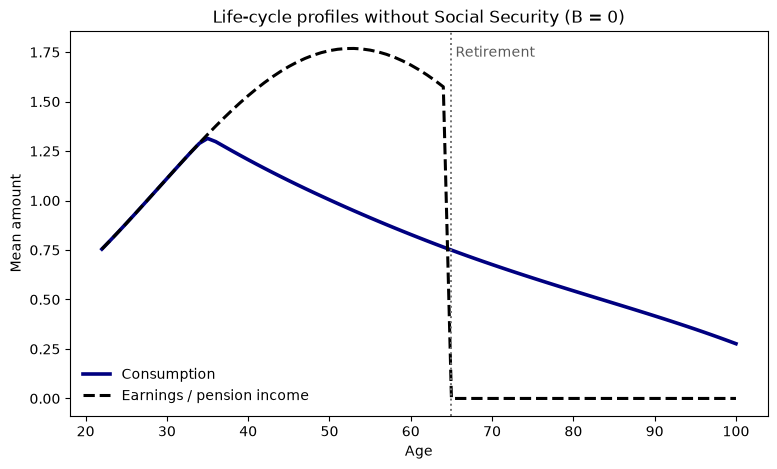

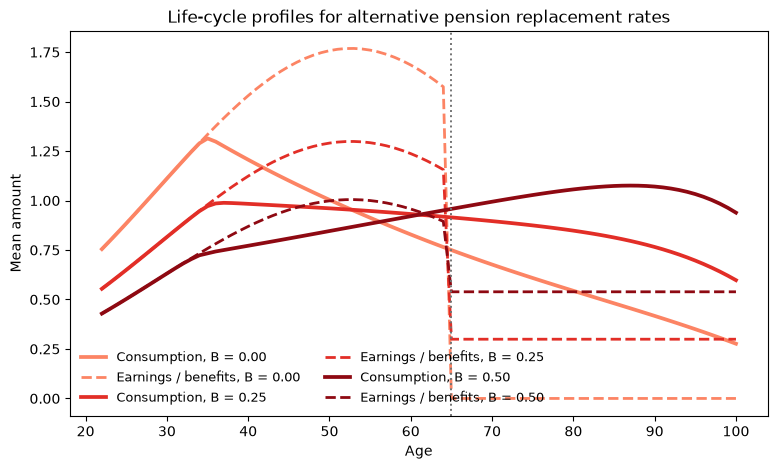

In [2]:
# Stationary equilibria and age profiles
# B is a constant pension replacement rate; darker red means a more generous pension.
B_values = [0.0, 0.25, 0.50]
equilibria = {}
K_guess = 5.0
for B in B_values:
    equilibria[B] = solve_equilibrium(B, K_initial=K_guess)
    K_guess = equilibria[B]['K']
    eq = equilibria[B]
    print(f"B = {B:.2f}: K = {eq['K']:.3f}, r = {eq['r']:.3%}, payroll tax = {eq['tax']:.3%}, iterations = {eq['iterations']}")

# 1. No Social Security: solid consumption and dashed earnings
eq0 = equilibria[0.0]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(age, eq0['consumption'], color='navy', lw=2.6, label='Consumption')
ax.plot(age, eq0['earnings'], color='black', lw=2.2, ls='--', label='Earnings / pension income')
ax.axvline(65, color='0.45', ls=':', lw=1.4)
ax.text(65.5, ax.get_ylim()[1] * 0.93, 'Retirement', color='0.35')
ax.set(title='Life-cycle profiles without Social Security (B = 0)', xlabel='Age', ylabel='Mean amount')
ax.legend(frameon=False)
plt.show()

# 2. Alternative pension replacement rates: solid consumption, dashed earnings / benefits
red_scale = plt.cm.Reds(np.linspace(0.42, 0.92, len(B_values)))
fig, ax = plt.subplots(figsize=(9, 5))
for B, color in zip(B_values, red_scale):
    eq = equilibria[B]
    ax.plot(age, eq['consumption'], color=color, lw=2.7, label=f'Consumption, B = {B:.2f}')
    ax.plot(age, eq['earnings'], color=color, lw=2.0, ls='--', label=f'Earnings / benefits, B = {B:.2f}')
ax.axvline(65, color='0.45', ls=':', lw=1.4)
ax.set(title='Life-cycle profiles for alternative pension replacement rates', xlabel='Age', ylabel='Mean amount')
ax.legend(ncol=2, frameon=False, fontsize=9)
plt.show()
